## MLFlow avec Pyspark

Avant de commencer, installez Spark en local en suivant le guide "Spark Installation.pdf"

Nous allons suivre la même démarche que nous avons utilisé dans le premier notebook. 

Nous allons utilisé aussi le même dataset 

In [4]:
import os
os.environ["JAVA_HOME"] = "/Users/alfarouq/.sdkman/candidates/java/current"
import pyspark #
from pyspark.sql import SparkSession
from pyspark import SparkConf, SparkContext
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
import pyspark.sql.functions as F
import seaborn as sns
import sklearn #
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib #
import matplotlib.pyplot as plt
import mlflow
import mlflow.spark
os.environ["SPARK_LOCAL_IP"]='127.0.0.1'
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark.sparkContext._conf.getAll()
print("pyspark: {}".format(pyspark.__version__))
print("matplotlib: {}".format(matplotlib.__version__))
print("seaborn: {}".format(sns.__version__))
print("sklearn: {}".format(sklearn.__version__))
print("mlflow: {}".format(mlflow.__version__))

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/15 21:19:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


pyspark: 4.0.1
matplotlib: 3.10.7
seaborn: 0.13.2
sklearn: 1.7.2
mlflow: 3.6.0


In [5]:
data_path = 'data/creditcard.csv'
df = spark.read.csv(data_path, header = True,
inferSchema = True)
labelColumn = "Class"
columns = df.columns
numericCols = columns
numericCols.remove("Time")
numericCols.remove(labelColumn)
print(numericCols)

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [6]:
df.toPandas().head()

25/11/15 21:21:33 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
stages = []
assemblerInputs = numericCols
assembler = VectorAssembler(inputCols=assemblerInputs,
outputCol="features")
stages += [assembler]
dfFeatures = df.select(F.col(labelColumn).alias('label'),*numericCols )
normal = dfFeatures.filter("Class == 0").sample(withReplacement=False, fraction=0.5, seed=2020)
anomaly = dfFeatures.filter("Class == 1")
normal_train, normal_test = normal.randomSplit([0.8, 0.2],seed = 2020)
anomaly_train, anomaly_test = anomaly.randomSplit([0.8, 0.2],seed = 2020)

In [8]:
dfFeatures.toPandas().head()

,label,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [9]:
train_set = normal_train.union(anomaly_train)
test_set = normal_test.union(anomaly_test)

In [10]:
pipeline = Pipeline(stages = stages)
pipelineModel = pipeline.fit(dfFeatures)
train_set = pipelineModel.transform(train_set)
test_set = pipelineModel.transform(test_set)
selectedCols = ['label', 'features'] + numericCols
train_set = train_set.select(selectedCols)
test_set = test_set.select(selectedCols)
print("Training Dataset Count: ", train_set.count())
print("Test Dataset Count: ", test_set.count())

Training Dataset Count:  114389


Test Dataset Count:  28459


In [11]:
def train(spark_model, train_set):
    trained_model = spark_model.fit(train_set)
    trainingSummary = trained_model.summary
    pyspark_auc_score = trainingSummary.areaUnderROC
    mlflow.log_metric("train_acc", trainingSummary.accuracy)
    mlflow.log_metric("train_AUC", pyspark_auc_score)
    print("Training Accuracy: ", trainingSummary.accuracy)
    print("Training AUC:", pyspark_auc_score)
    return trained_model

In [12]:
def evaluate(spark_model, test_set):
    evaluation_summary = spark_model.evaluate(test_set)
    eval_acc = evaluation_summary.accuracy
    eval_AUC = evaluation_summary.areaUnderROC
    mlflow.log_metric("eval_acc", eval_acc)
    mlflow.log_metric("eval_AUC", eval_AUC)
    print("Evaluation Accuracy: ", eval_acc)
    print("Evaluation AUC: ", eval_AUC)

In [14]:
lr = LogisticRegression(featuresCol = 'features', labelCol ='label', maxIter=10)
mlflow.set_experiment("PySpark_CreditCard")
with mlflow.start_run():
    trainedLR = train(lr, train_set)
    evaluate(trainedLR, test_set)
    mlflow.spark.log_model(trainedLR,"creditcard_model_pyspark")
mlflow.end_run()

Training Accuracy:  0.9989247217826889
Training AUC: 0.9850460156339104
Evaluation Accuracy:  0.9989458519273341
Evaluation AUC:  0.9774990799474446


2025/11/15 21:24:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


## Loading the model

copiez l'ID run a partir de l'interface MLFlow 

In [15]:
model = mlflow.spark.load_model("runs:/716b8a4f68e4423cbe8c224f2ce82ba5/creditcard_model_pyspark")

2025/11/15 21:24:35 INFO mlflow.spark: URI 'runs:/716b8a4f68e4423cbe8c224f2ce82ba5/creditcard_model_pyspark/sparkml' does not point to the current DFS.
2025/11/15 21:24:35 INFO mlflow.spark: File 'runs:/716b8a4f68e4423cbe8c224f2ce82ba5/creditcard_model_pyspark/sparkml' not found on DFS. Will attempt to upload the file.


In [16]:
predictions = model.transform(test_set)
y_true = predictions.select(['label']).collect()
y_pred = predictions.select(['prediction']).collect()

In [17]:
print(f"AUC Score: {roc_auc_score(y_true, y_pred):.3%}")
print(f"Accuracy Score: {accuracy_score(y_true, y_pred):.3%}")

AUC Score: 88.354%
Accuracy Score: 99.895%


Text(0.5, 23.52222222222222, 'Predicted')

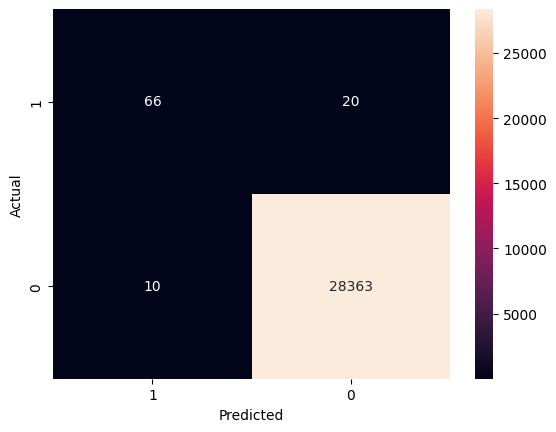

In [18]:
conf_matrix = confusion_matrix(y_true, y_pred)
ax = sns.heatmap(conf_matrix, annot=True,fmt='g')
ax.invert_xaxis()
ax.invert_yaxis()
plt.ylabel('Actual')
plt.xlabel('Predicted')